<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_3_WorkGroupDataMinning/blob/main/Week01/WorkGroup/DAMI_CP_W1_E10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 1: Análisis Exploratorio de Datos – Adult Income Dataset


# 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
- Versión: 1.0.0
- Licencia: MIT


### **🎯 Introducción:**

El objetivo de esta tarea es realizar un análisis exploratorio de datos completo sobre el dataset Adult Income. Se deberá identificar patrones, relaciones y factores que influyen en el ingreso de las personas (>50K), y presentar sus hallazgos en un notebook y un PDF resumen.

### **🌍 Contexto del trabajo**

El dataset Adult Income contiene información de censos de individuos incluyendo edad, educación, sexo, horas trabajadas, ocupación, ganancias y pérdidas de capital, entre otras variables. La variable objetivo es 'income' (<=50K, >50K)

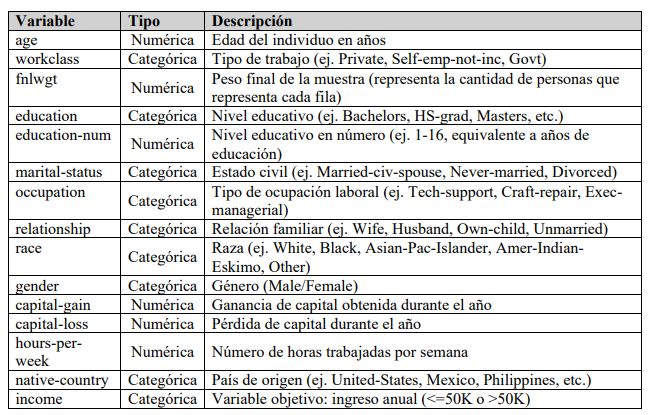

### **✅ Objetivos**

1️⃣ Cargar y preparar los datos.

2️⃣ Realizar estadísticas descriptivas de variables numéricas y categóricas.

3️⃣ Analizar distribuciones univariadas y detectar outliers.

4️⃣ Explorar relaciones bivariadas entre variables y la variable objetivo.

5️⃣ Generar gráficos tipo subplot, boxplots, countplots e histogramas.

6️⃣ Calcular la matriz de correlación y visualizarla con heatmap.

7️⃣ Identificar hallazgos y conclusiones relevantes.

8️⃣ Presentar el trabajo en un notebook y un PDF resumen con gráficos y
conclusiones.

# 🏗️ Carga y preparación de datos

*******************************************************************************

## 🔗 Enlaces del Dataset que se usaran

La información que usaremos para esta práctica es un dataset proporcionado por el docente que estará disponible en el siguiente enlace: https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week01/WorkGroup/dataset/adult.csv


## 🚀 Descarga del dataset

In [2]:
 # importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define el nombre del archivo csv que se descargará
adult_file_path = 'adult.csv'

# Descarga el archivo csv del dataset
# El archivo se guarda en el entorno de trabajo actual y valido que si existe no lo descargue de nuevo

if not os.path.exists(adult_file_path) and not os.path.exists(adult_file_path):
  !wget --timeout=15 --tries=2 'https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week01/WorkGroup/dataset/adult.csv' -O '{adult_file_path}'
  print(f'Archivo {adult_file_path} descargado')
else:
  print(f'Archivo {adult_file_path} ya existe')

# Cargamos el archivo csv para continuar con el ejercicio
df = pd.read_csv(adult_file_path)

--2026-07-13 19:05:48--  https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week01/WorkGroup/dataset/adult.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5326368 (5.1M) [text/plain]
Saving to: ‘adult.csv’

adult.csv           100%[===================>]   5.08M  --.-KB/s    in 0.1s    

2026-07-13 19:05:48 (46.6 MB/s) - ‘adult.csv’ saved [5326368/5326368]

Archivo adult.csv descargado


## 🚀 Previsualizacion y validacion

📥 Se valida los datos que tenemos actualmente y visualizamos sus columnas y sus tipos de datos

In [3]:
# Visualizamos un breve informacion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


# 🔍 Estadísticas descriptivas

En esta sección analizaremos las columnas por su tipo de dato e interpretaremos su contenido.

En las columnas numericas tenemos un conteo de 48842 registros en el conjunto de datos donde las columnas que son númericas son: **age, fnlwgt, educational-num,	capital-gain, capital-loss, hours-per-week**. Las cuales ya teniamos un primer vistazo en la tabla que se nos fue brindada para este trabajo. A continuación interpretaremos el conjunto de datos:

- **En la columna edad**: podemos notar que la edad media es de 38,6 años, la persona de menor edad es de 17 años y la edad máxima es de 90 años que nos dice que pueden existir outliers debido a esta diferiencia de edad.

- **El peso final** al ser un valor de ponderación de este censo que por ello no se tomará  en cuenta.

- **El nivel educativo de las personas censadas** esta en promedio de 10 años con un maximo de 16 años que existe personas muy preparadas y notando el minimo de 1 año quiere decir que tenemos personas que apenas pudieron estudiar.

- **El capital ganado** miramos que tenemos un máximo con un valor que no puede ser real, parece un valor de relleno que puede tomarse como un outlier, por otro lado el promedio de ganancias de las personas de este censo es de $ 1079 y una mínima de 0. Al revisar estos datos nos puede decir que tenemos un dataset muy variado que puede contener outliers que pueden afectar a nuestro analisis.

- **El capital perdido** nos muestra que tenemos una media de perdida de $87, una mínima de $0 y una maxima de $4356 que nos dice que estas personas casi no perdieron dinero pero la máxima llama la atención por lo exhuberante cantidad que expone y tendriamos que analizar ese caso.

- **En las horas trabajadas** tenemos una media de 40 horas por semana, el minimo es de 1 hora y un máximo nos dice que es 99 horas. El valor máximo llama la atención debido a la que es un valor irreal pero eso tenemos que analizarlo en otra sección.



In [4]:
# Muestra un resumen estadístico de las columnas numéricas del dataset
df.describe(include='number')

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Por otro lado, para los objetos tenemos una estadistica diferente que nos hace resaltar otras interpretaciones, pero la cantidad de registros se mantiene como en la anterior revisión. Las columnas de tipo de dato objeto tenemos: **workclass, education, marital-status, occupation, relationship, race, gender	native-country,	income**. A continuación interpretaremos los datos:


- **En el tipo de trabajo**: Existen 9 categorias en esta columna que la más comun es Private que aparece al menos 33906.
- **En el nivel educativo**: Existen 16 categorias de las cuales "HS-grad" es el más común con una frecuencia de 15784.
- **En el estado civil**: Existen 7 categorias donde la categoria "Married-civ-spouse" con una frecuencia de 22379.
- **En la ocupación**: Existen 15 categorias donde la categoria "Prof-specialty" es la más fecuente con una frecuencia 6172 veces.
- **La relación familiar**: Existe 6 categorias donde la categoria más comun es "Husband" con una frecuencia de 19716.
- **La raza o étnia**: Existe 5 categorias donde la categoria es más frecuente es "White" con una frecuencia de 41762 que nos dice que la mayoria del dataset pertenece a esta étnia.
- **El género**: Existe 2 categorias donde la categoria más común es "Male" con una frecuencia de 32650.
- **El país de origen**: Existe 42 categorias donde la más común es "United-States" con una frecuencia de 43832, donde esto nos confirma que es un censo en la población americana.
- **Ingresos**: Existe 2 categorias donde la más frecuente es "<=50k" con una frecuencia de 37155 veces.

En conclusión, tenemos un conjunto de datos con varidad que nos permitirá realizar un analisis más completo, pero tenemos que revisar si existen registros faltantes en las columnas de categorias.



In [5]:
# Muestra un resumen estadístico de las columnas objetos
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


## 🚀 Gráficos de cada columna por tipo de dato númerico

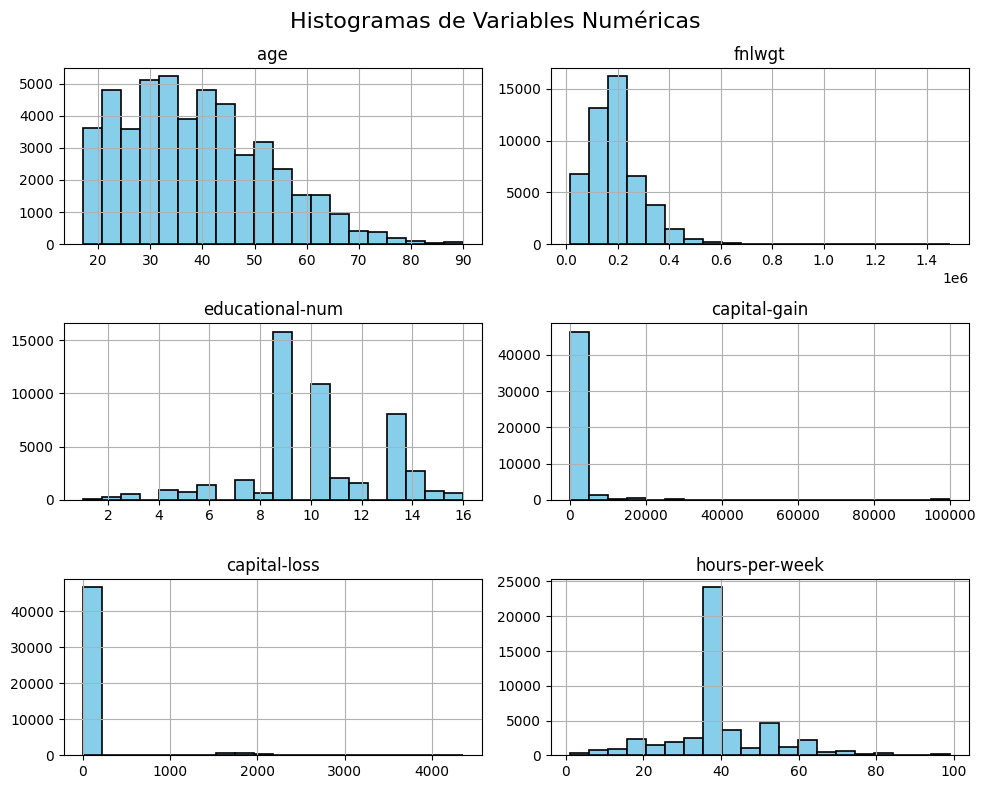

In [6]:
# Gráficamos las columnas en un histograma para el tipo de dato de number
# Seleccionar variables numéricas
df_num = df.select_dtypes(include='number')

# Histogramas
df_num.hist(figsize=(10,8),
            color='skyblue',      # Color de las barras
            edgecolor='black',    # Color del borde
            linewidth=1.2,         # Grosor del borde
            bins=20)

plt.suptitle("Histogramas de Variables Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

## 🚀 Gráficos de cada columna por tipo de dato objeto

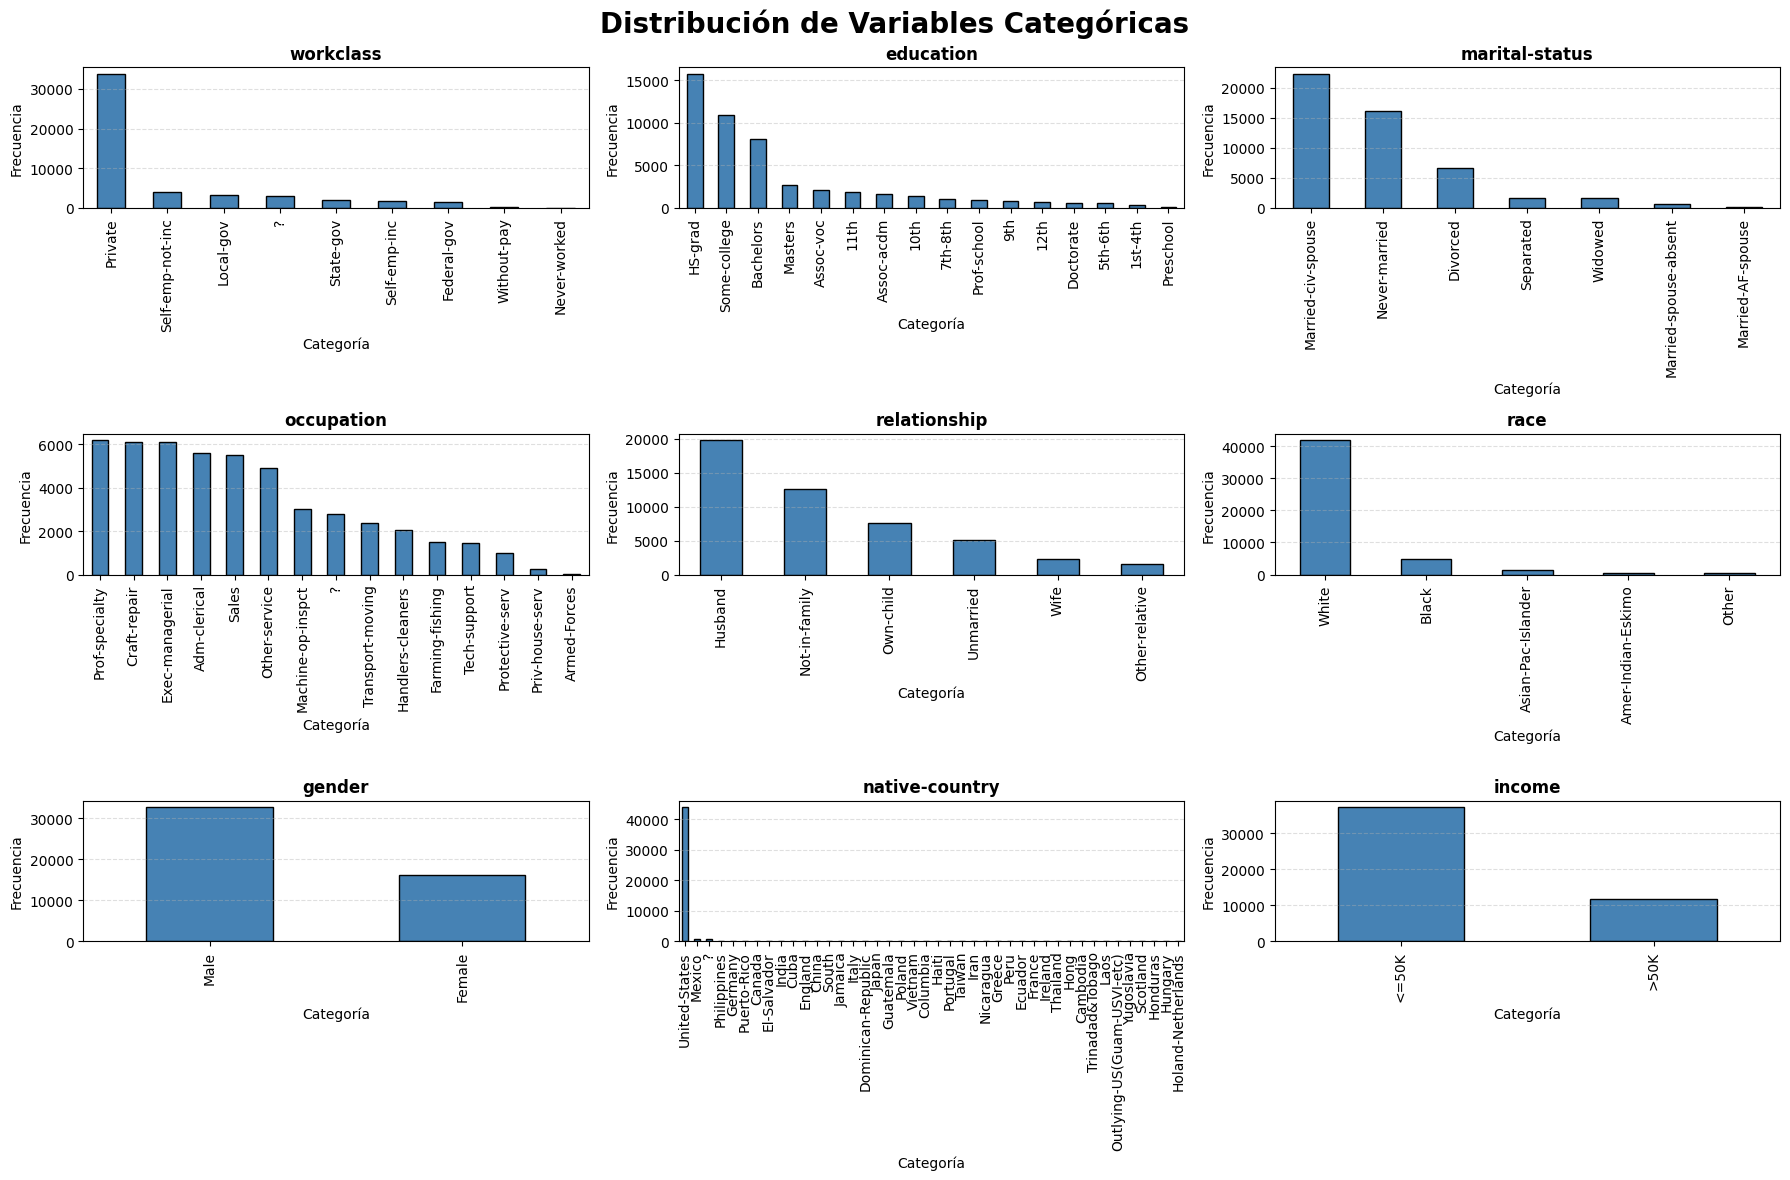

In [7]:
# Gráficamos las columnas en un histograma para el tipo de dato de object
# Variables categóricas
df_object = df.select_dtypes(include='object').columns

# Crear una cuadrícula de gráficos
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,12))

# Convertir la matriz de ejes en un vector
axes = axes.flatten()

# Dibujar cada gráfico
for i, col in enumerate(df_object):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        color='steelblue',
        edgecolor='black'
    )

    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

# Si sobran ejes, eliminarlos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Categóricas", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# 🔍 Distribuciones univariadas


En esta sección, vamos a realizar el análisis detallado de cada columna para ver que patrones encontramos dentro de los datos y con eso determinar posibles valores atipico en los registros y si son compartidos entre todas las columnas los datos. Las columnas más interesantes para realizar el análisis univariable sería: **age, workclass, education, marital-status, occupation, relationship, race, gender, hours-per-weeek, income**

## 🚀 Age

In [8]:
## Como analizamos previamente la edad esta distribuida desde 17 a 90 años
df['age'].describe()

,age
count,48842.000000
mean,38.643585
std,13.710510
min,17.000000
25%,28.000000
50%,37.000000
75%,48.000000
max,90.000000


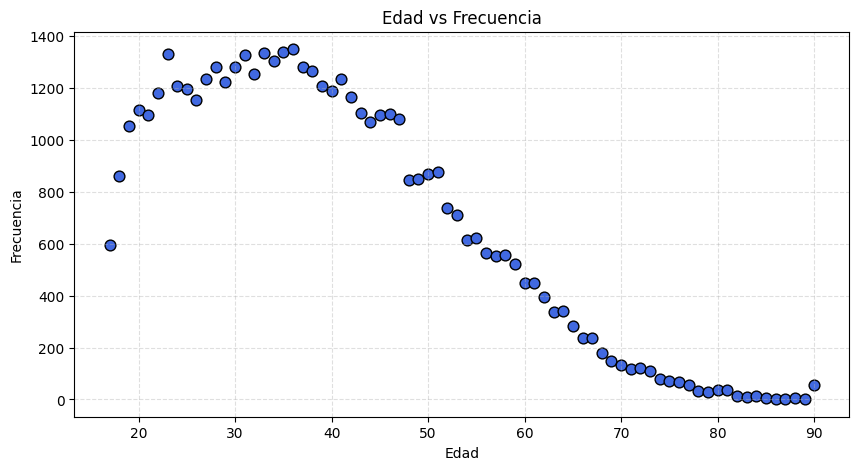

In [9]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["age"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Edad
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Edad vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna alcanzamos a ver una distribución más una gráfica de seno por su frecuencia. Encontramos que exuste más frecuencia en el rango de edades de 20 a 40 años que es la edad de la población laboralmente activa del país. Y se nota una clara caida desde los 40 años hasta lo 90 años que ya son edades donde son menos activos laboralmente. Para este caso no podemos notar outliers debido a la cantidad de registros y es muy ambiguo de interpretarlo en un gráfico de frecuencia.

## 🚀 WorkClass

In [10]:
## Como analizamos previamente la edad esta distribuida en 9 categorias donde predomina "Private"
df['workclass'].describe()

,workclass
count,48842
unique,9
top,Private
freq,33906


In [11]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores Antes  Cambio Categoria")
df['workclass'].value_counts()

Valores Antes  Cambio Categoria


,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
?,2799
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [12]:
# Como encontramos que existe una categoria ? que no tiene valor y lo vamos a cambiar por "Unknown"

df['workclass'] = df['workclass'].replace('?', 'Unknown')

print("Valores Despues Cambio Categoria")
df['workclass'].value_counts()

Valores Despues Cambio Categoria


,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
Unknown,2799
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


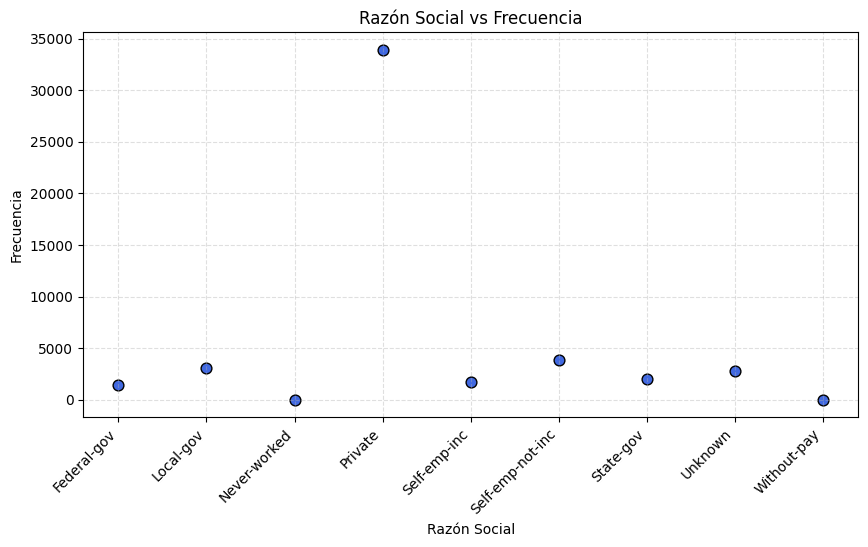

In [13]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["workclass"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # WorkClass
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Razón Social")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Razón Social vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna alcanzamos a notar que la categoria "Private" tiene la mayor frecuencia como notamos y le sigue la categoria de "Self-emp-not-inc". Por otro lado, encontramos categoria en incognito que deberiamos verificar y colocarle un valor de categoria llamada "Unknown" para tenerla con un nombre.

## 🚀 Education

In [14]:
## Como analizamos previamente la edad esta distribuida en 9 categorias donde predomina "Private"
df['education'].describe()

,education
count,48842
unique,16
top,HS-grad
freq,15784


In [15]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores de Categoria")
df['education'].value_counts()

Valores de Categoria


,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


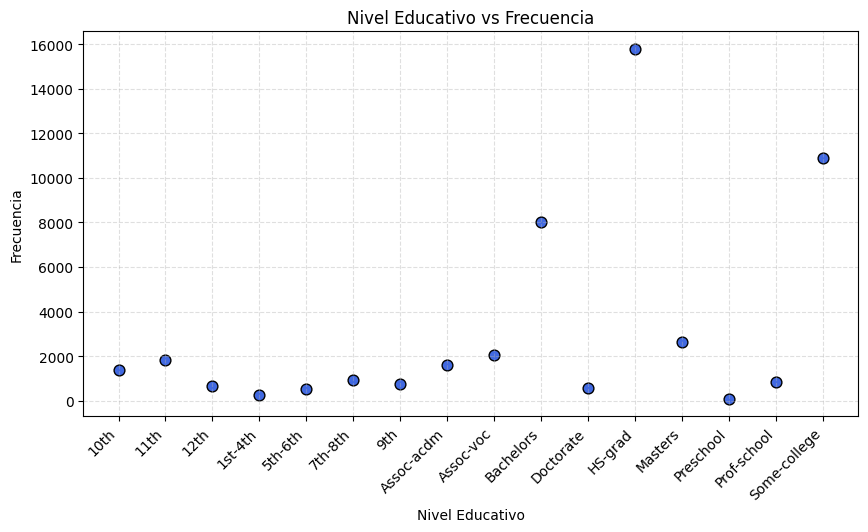

In [16]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["education"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Nivel Educativo
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Nivel Educativo")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Nivel Educativo vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna interpetamos que existen muchas personas con nivel de Secundaria y le sigue el "Some-college" como el segundo nivel educativo. No se encontro datos extraños dentro de los datos por el momento para esta columna.

## 🚀 Marital-Status

In [17]:
## Como analizamos previamente la edad esta distribuida en 9 categorias donde predomina "Married-civ-spouse"
df['marital-status'].describe()

,marital-status
count,48842
unique,7
top,Married-civ-spouse
freq,22379


In [18]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores de Categoria")
df['marital-status'].value_counts()

Valores de Categoria


,count
marital-status,
Married-civ-spouse,22379
Never-married,16117
Divorced,6633
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


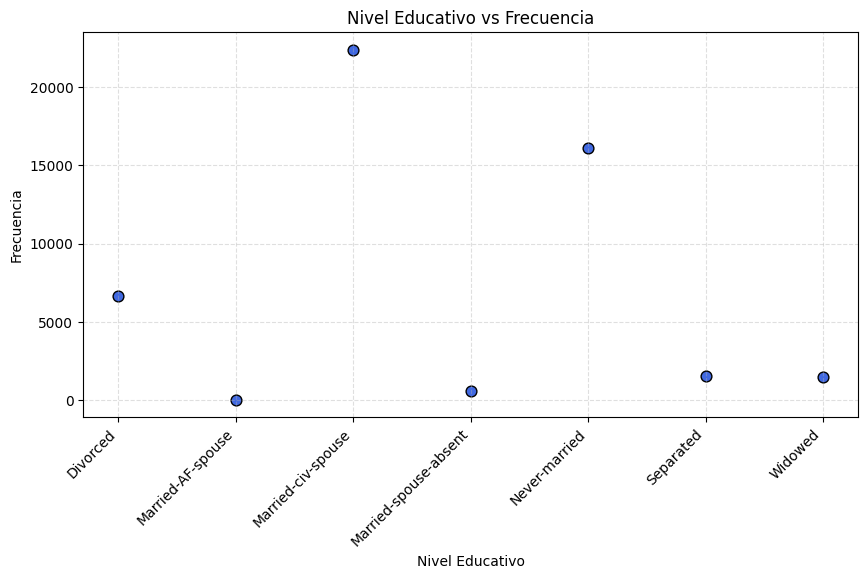

In [19]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["marital-status"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Estado Civil
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Nivel Educativo")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Nivel Educativo vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna podemos interpretar que el segundo grupo de estado civil es "Never-married" que puede considerarse entre solteros o union libre conocido en latinoamerica. Por ahora en esta columna no encontramos ningun valor atípico.

## 🚀 Occupation

In [20]:
## Como analizamos previamente la edad esta distribuida en 9 categorias donde predomina "Prof-specialty"
df['occupation'].describe()

,occupation
count,48842
unique,15
top,Prof-specialty
freq,6172


In [21]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores Antes  Cambio Categoria")
df['occupation'].value_counts()

Valores Antes  Cambio Categoria


,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
?,2809
Transport-moving,2355


In [22]:
# Como encontramos que existe una categoria ? que no tiene valor y lo vamos a cambiar por "Unknown"

df['occupation'] = df['occupation'].replace('?', 'Unknown')

print("Valores Despues Cambio Categoria")
df['occupation'].value_counts()

Valores Despues Cambio Categoria


,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
Unknown,2809
Transport-moving,2355


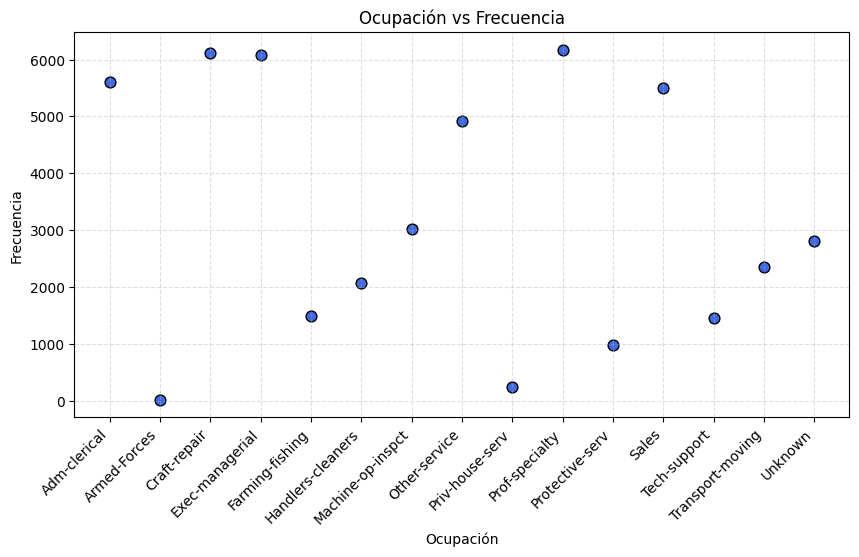

In [23]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["occupation"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Ocupación
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Ocupación")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Ocupación vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna podemos interpretar que esta encuesta tiene más personas con especialidades, reparación o creación artesanal y gerencia. Por ahora en esta columna no encontramos ningun valor atípico.

## 🚀 Relationship

In [24]:
## Como analizamos previamente la edad esta distribuida en 6 categorias donde predomina "Husband"
df['relationship'].describe()

,relationship
count,48842
unique,6
top,Husband
freq,19716


In [25]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores de Categoria")
df['relationship'].value_counts()

Valores de Categoria


,count
relationship,
Husband,19716
Not-in-family,12583
Own-child,7581
Unmarried,5125
Wife,2331
Other-relative,1506


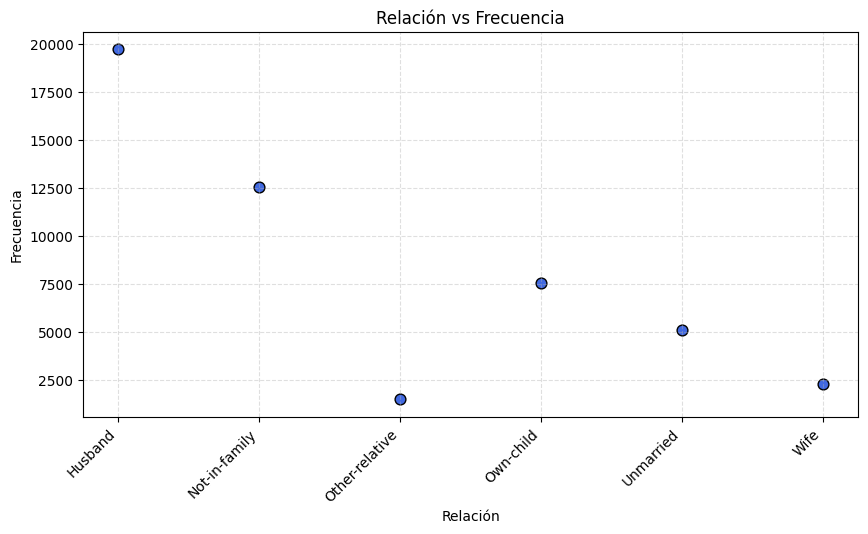

In [26]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["relationship"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Relación
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Relación")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Relación vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna podemos interpretar que las personas que no tienen familia son la segunda categoria más frecuente y que no hay muchas esposas dentro de la encuesta. Quiere decir que hay poca relaciones estables en este conjunto de datos pero eso es subjetivo de acuerdo a lo que observamos.




## 🚀 Race

In [27]:
## Como analizamos previamente la edad esta distribuida en 5 categorias donde predomina "White"
df['race'].describe()

,race
count,48842
unique,5
top,White
freq,41762


In [31]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores de Categoria")
df['race'].value_counts()

Valores de Categoria


,count
race,
White,41762
Black,4685
Asian-Pac-Islander,1519
Amer-Indian-Eskimo,470
Other,406


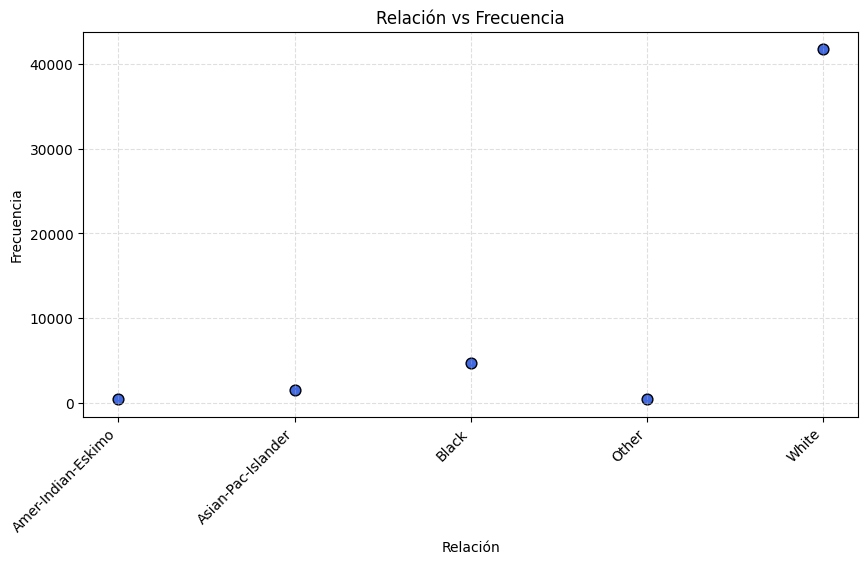

In [32]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["race"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Etnia
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Etnia")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Etnia vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna podemos interpretar que existe mayor población de etnia blanca y la diversidad de etnias es baja considerando la cantidad de la muestra. Por el momento, no hemos encontrado datos incompletos.



## 🚀 Gender

In [33]:
## Como analizamos previamente la edad esta distribuida en 2 categorias donde predomina "Male"
df['gender'].describe()

,gender
count,48842
unique,2
top,Male
freq,32650


In [34]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores de Categoria")
df['gender'].value_counts()

Valores de Categoria


,count
gender,
Male,32650
Female,16192


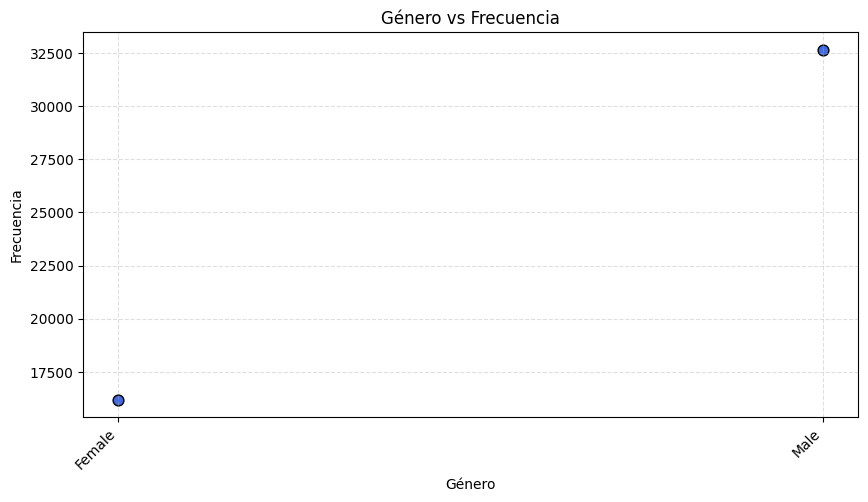

In [35]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["gender"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Género
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Género")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Género vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna podemos interpretar que solo existe dos generos para este conjunto de datos


## 🚀 Hours-Per-Week

In [39]:
## Como analizamos previamente las horas por semana de trabajo una media de 40 horas
df['hours-per-week'].describe()

,hours-per-week
count,48842.000000
mean,40.422382
std,12.391444
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


In [41]:
# Revisemos los valores como estan formateados de esta columna

df['hours-per-week'].value_counts()

,count
hours-per-week,
40,22803
50,4246
45,2717
60,2177
35,1937
...,...
79,1
94,1
87,1


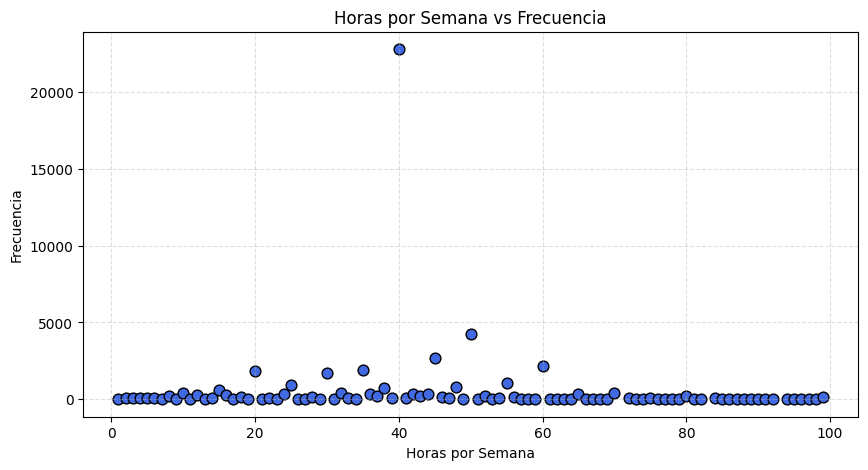

In [42]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["hours-per-week"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Horas por Semana
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Horas por Semana")
plt.ylabel("Frecuencia")
plt.title("Horas por Semana vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna tenemos algo interesante que gran parte de las personas trabaja 40 horas a la semana que quiere decir que tiene un trabajo estable que tener mas tiempo de trabajo que puede entrar en emprendimientos o diferentes profesiones que permite ganar dinero pero no el suficiente y tienen que trabajar más para obtener lo mismo. Por el momento encontramos que si tenemos outliers con el tiempo por semana con registros con 1 solo registro.


## 🚀 Income

In [48]:
## Como analizamos previamente los ingresos esta en dos categorias
df['income'].describe()

,income
count,48842
unique,2
top,<=50K
freq,37155


In [49]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores Categoria")
df['income'].value_counts()

Valores Antes  Cambio Categoria


,count
income,
<=50K,37155
>50K,11687


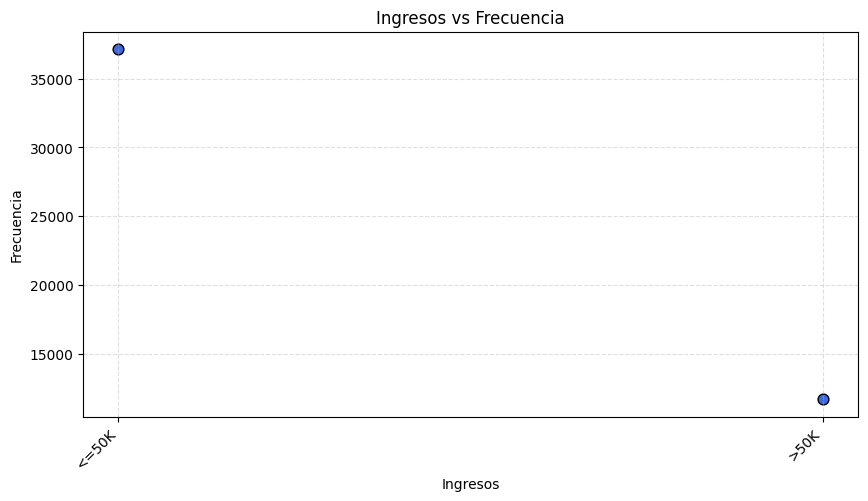

In [51]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["income"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # Ingresos
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("Ingresos")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("Ingresos vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna tenemos la categoria de ingresos que cada persona comentó en la encuesta del censo donde tenemos una mayoria los menores de 50k.


## 🚀 Native Country

In [ ]:
## Como analizamos previamente este censo fue realizado en USA y tenemos datos de la población de este país
df['native-country'].describe()

,native-country
count,48842
unique,42
top,United-States
freq,43832


In [ ]:
# Realizamos el conteo por categoria para detectar posibles valores nulos o incompleto.

print("Valores Antes  Cambio Categoria")
df['native-country'].value_counts()

Valores Antes  Cambio Categoria


,count
native-country,
United-States,43832
Mexico,951
?,857
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151


In [ ]:
# Como encontramos que existe una categoria ? que no tiene valor y lo vamos a cambiar por "Unknown"

df['native-country'] = df['native-country'].replace('?', 'Unknown')

print("Valores Despues Cambio Categoria")
df['native-country'].value_counts()

Valores Despues Cambio Categoria


,count
native-country,
United-States,43832
Mexico,951
Unknown,857
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151


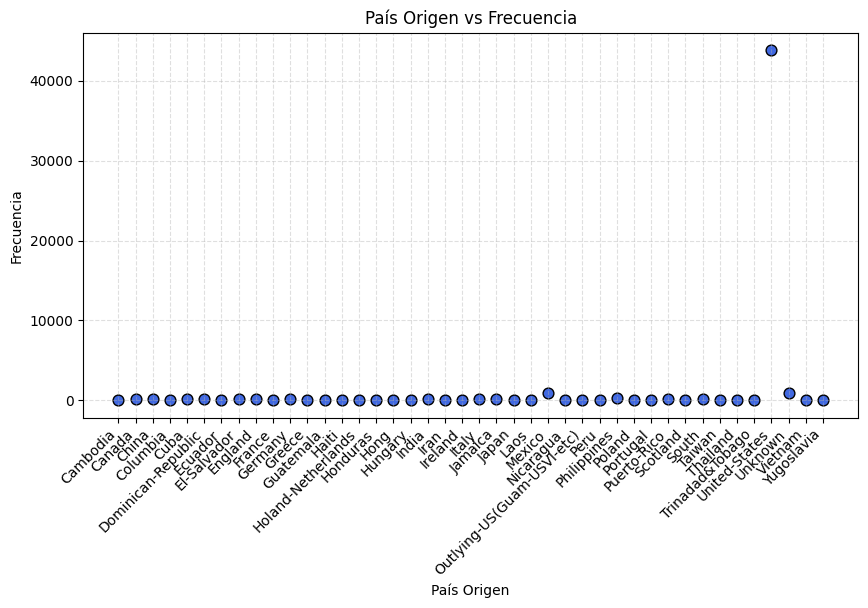

In [ ]:
# Distribuyendo los datos en un gráfico tenemos lo siguiente

conteo = df["native-country"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.scatter(
    conteo.index,      # País Origen
    conteo.values,     # Cantidad de personas
    color="royalblue",
    s=60,
    edgecolors="black"
)

plt.xlabel("País Origen")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frecuencia")
plt.title("País Origen vs Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

### 🧠 Interpretación

En esta columna tenemos que la cantidad de nacionalidades es bastante pero su cantidad de registros no es mayor al total de personas de US.


## 🧹 Limpieza  y Validación de Columnas

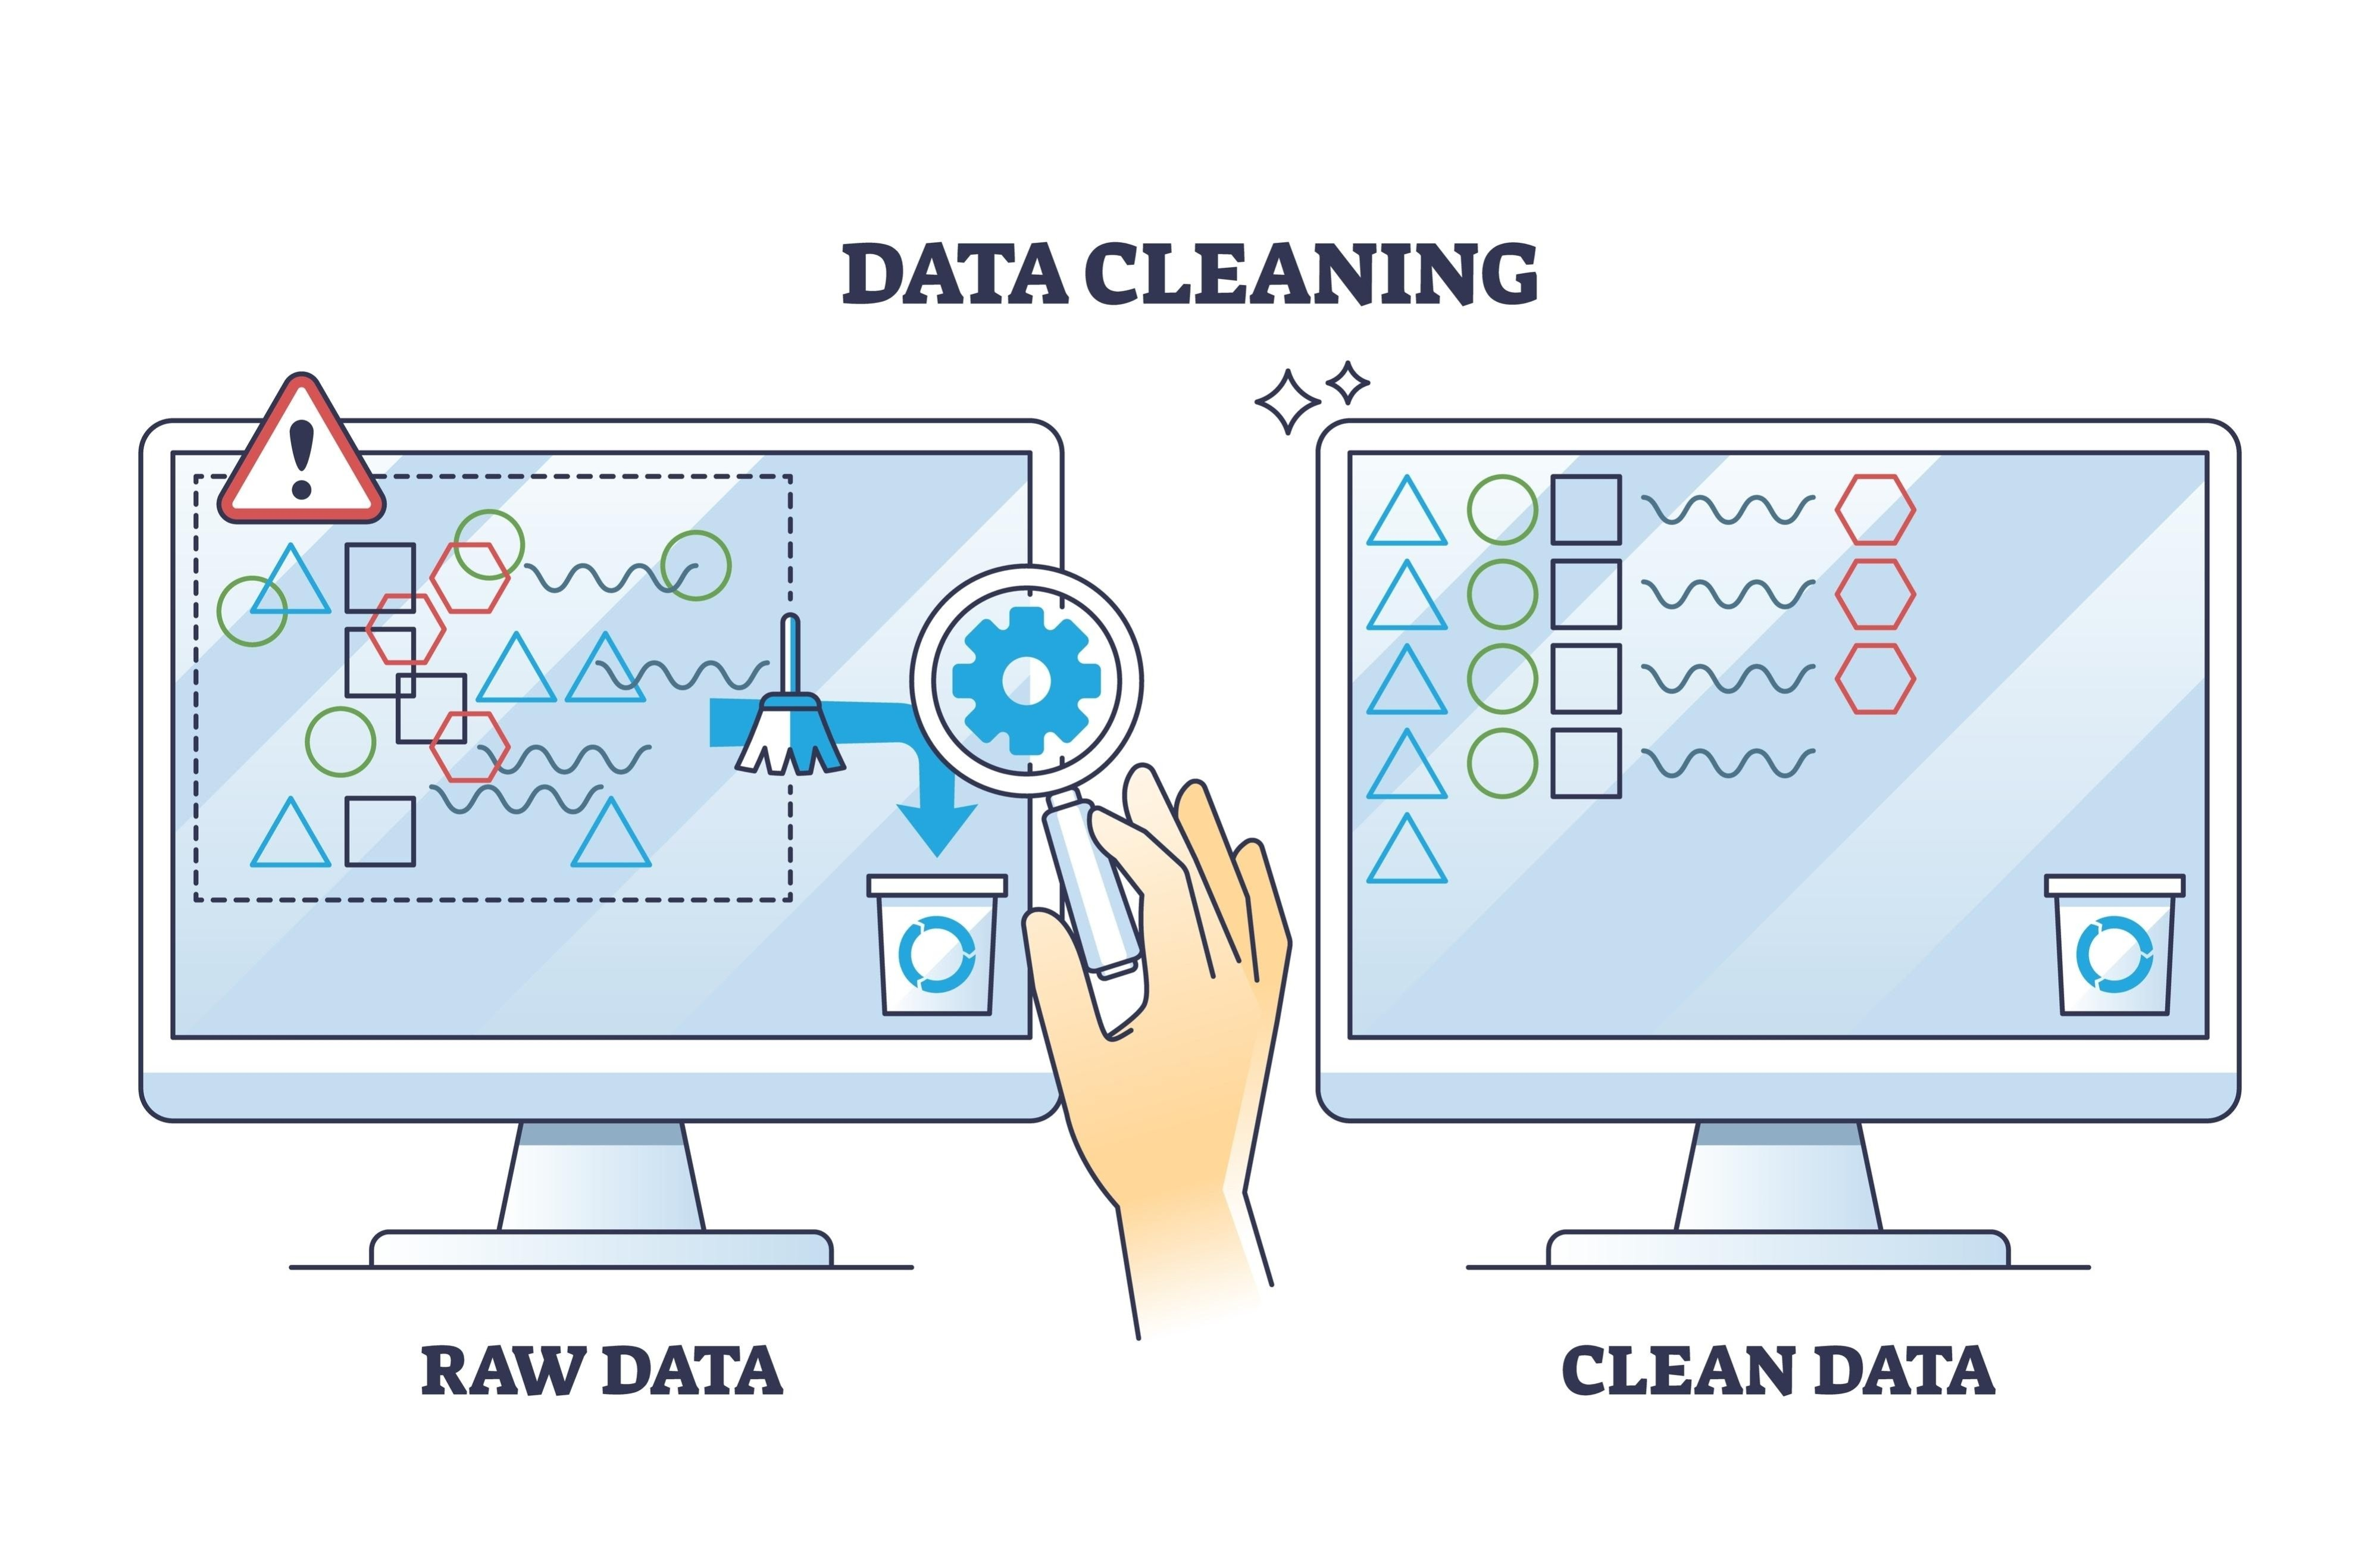

## 🧹 Tratamiento de Valores Nulos
Para garantizar que el análisis sea estadísticamente significativo y técnicamente eficiente, se han aplicado las siguientes reglas de procesamiento sobre el dataset:

Identificar las columnas que presentan más del 30 % de valores nulos para decidir su eliminación.
Adicional, se reviso las columnas por la varianza para eliminar aquellas que no sean necesarias.
En el caso de columnas críticas con pocos valores faltantes, se realiza la imputación de datos.

El código **analiza los valores nulos**, elimina las columnas con **más del 30 % de datos faltantes** y muestra un **comparativo del número de columnas antes y después** del proceso de limpieza.


In [52]:
# Obtiene el número total de columnas del DataFrame original
total_columnas_antes = df.shape[1]
total_columnas_antes  # Muestra el total de columnas antes del tratamiento

# Calcula el porcentaje de valores nulos por cada columna
nulos = (
    df.isna()          # Identifica valores nulos (NaN)
      .mean()          # Calcula la proporción de nulos por columna
      .mul(100)        # Convierte la proporción a porcentaje
      .round(2)        # Redondea a 2 decimales
      .reset_index()   # Convierte el índice en una columna
)

# Renombra las columnas del DataFrame resultante
nulos.columns = ['Columna', 'Porcentaje_nulos']

# Selecciona las columnas que tienen más del 30% de valores nulos
columnas_mayor_30 = (
    nulos[nulos['Porcentaje_nulos'] > 30]['Columna']
    .tolist()          # Convierte los nombres de columnas a una lista
)

# Elimina del DataFrame las columnas con más del 30% de nulos
df_reducido = df.drop(columns=columnas_mayor_30)

# "Las columnas que tienen un valor único... probablemente sean inútiles"
for col in df_reducido.columns:
    if df_reducido[col].nunique() == 1:
        print(f"Eliminando columna de varianza cero: {col}")
        df_reducido = df_reducido.drop(columns=[col])

print(f"Dimensiones post-limpieza básica: {df_reducido.shape}")

# Obtiene el total de columnas después de eliminar las columnas con muchos nulos
total_columnas_despues = df_reducido.shape[1]
total_columnas_despues  # Muestra el total de columnas después del tratamiento

# Crea un DataFrame resumen con el antes y después del tratamiento de columnas
resumen_columnas = pd.DataFrame({
    'Estado': ['Antes del tratamiento', 'Después del tratamiento'],
    'Total_columnas': [total_columnas_antes, total_columnas_despues]
})

# Muestra el resumen final
resumen_columnas


Dimensiones post-limpieza básica: (48842, 15)


,Estado,Total_columnas
0,Antes del tratamiento,15
1,Después del tratamiento,15


Luego de validar, nos percatamos que no existen columnas para eliminar.

# 🔍 Análisis bivariado


En esta sección, vamos a realizar el analisis de varias variables que hemos revisado anteriormente. Combinaremos columnas de acuerdo a su contenido para responder posibles preguntas que puedan ayudar encontrar un patrón.

## 💭 ¿Tienen mayores ingresos las personas con estabilidad laboral con una familia?

Según lo que hemos analizado antes tenemos un grupo de personas que son casadas que si pueden tener familia donde muestra la gráfica tienen una porpoción de >0,55 respecto a las que ganan >50k esto nos muestra que tener una relación estable no es un determinante de que puedas tener mayores ganancias.

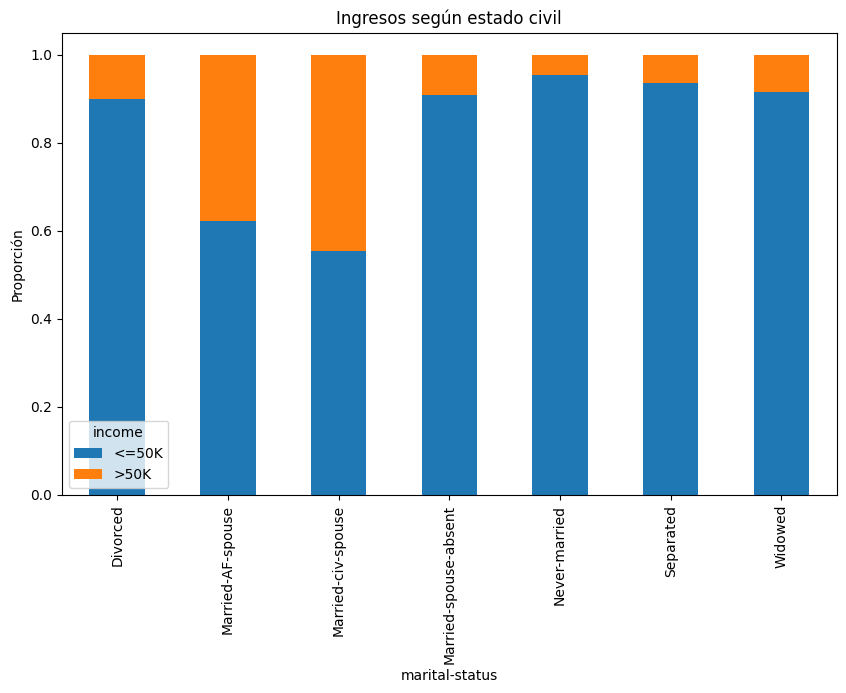

In [53]:
# Gráficamos con barras con las columnas de ingresos y estado civil para interpretar el resultado
(
    pd.crosstab(df["marital-status"], df["income"], normalize="index")
    .plot(kind="bar", stacked=True, figsize=(10,6))
)

plt.ylabel("Proporción")
plt.title("Ingresos según estado civil")
plt.show()

## 💭 ¿Las personas nacidas fuera de Estados Unidos presentan una mayor proporción de ingresos superiores a 50K que las nacidas en Estados Unidos?

Según lo que hemos analizado antes de los origenes tenemos varias nacionalidades dentro este conjunto de datos. Es interesante saber que ese grupo de personas que es menor a las personas que son estadounidenses existe una proporcion ligeramente menor que nos dice que no existe tanta diferencia entre los ciudadanos nativos y extranjeros

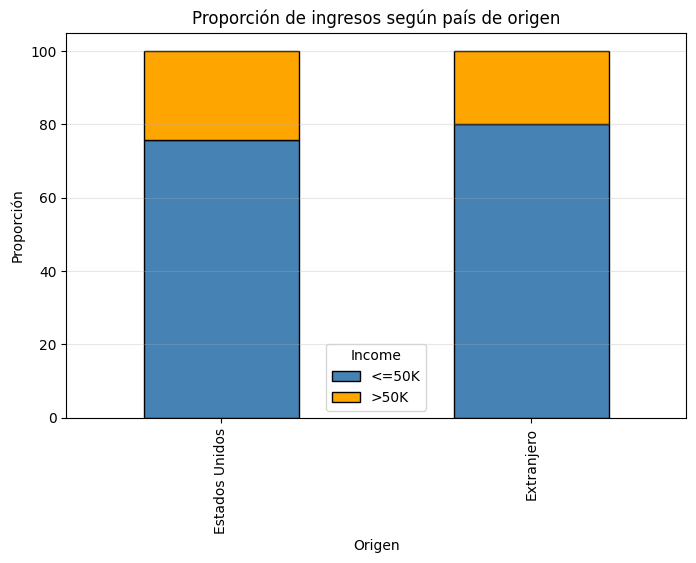

In [55]:
import numpy as np


# Creamos una nueva columna en el dataset para mencionar quienes son Extranjeros y quienes son Nativos del pais
df["origen"] = np.where(
    df["native-country"] == "United-States",
    "Estados Unidos",
    "Extranjero"
)

# Creamos una tabla de proporciones
tabla = pd.crosstab(
    df["origen"],
    df["income"],
    normalize="index"
) * 100

# Gráficamos la tabla
tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["steelblue", "orange"],
    edgecolor="black"
)

plt.title("Proporción de ingresos según país de origen")
plt.xlabel("Origen")
plt.ylabel("Proporción")
plt.legend(title="Income")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 💭 ¿Existe una diferiencia en los ingresos de una persona con mayor formación academica?

Según el gráfico notamos que si existe una diferencia en el salario de las personas con la formación academica que nos puede dar la interpretación que entre más se formen las personas tienen mayor probabilidad de tener mejor salario.

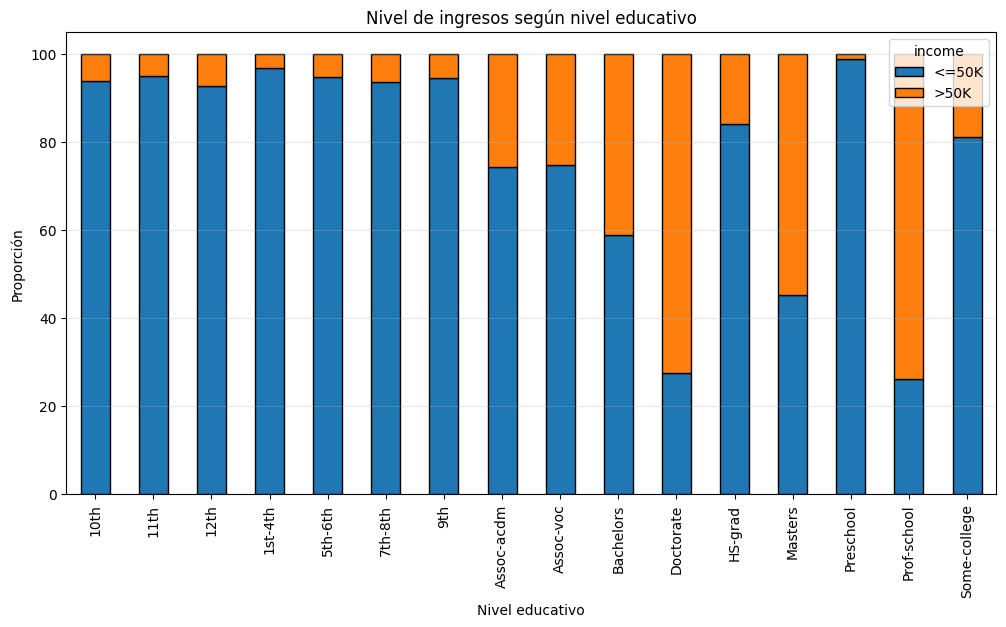

In [56]:
# Creamos la tabla entre la columna de formación academica con los ingresos
tabla = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

# Gráficamos el resultado

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    edgecolor="black"
)

plt.title("Nivel de ingresos según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Proporción")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 💭 ¿Cuáles son los trabajos con mayores ingresos?

Según los datos tenemos que entre mejor es el cargo mejor es el nivel de ingresos, ya que los cargos de gerente y especialistas tieden a tener mejores ingresos que aquellos trabajos que parecen no necesitar mucha formación

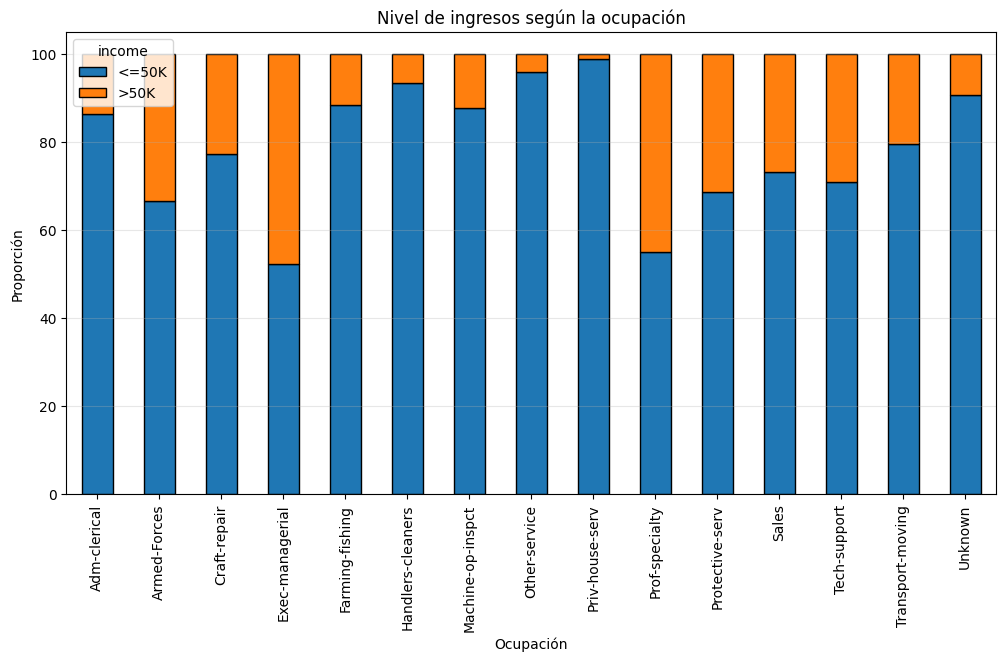

In [58]:
# Creamos la tabla entre la columna de la ocupación con los ingresos
tabla = pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
) * 100

# Gráficamos el resultado

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    edgecolor="black"
)

plt.title("Nivel de ingresos según la ocupación")
plt.xlabel("Ocupación")
plt.ylabel("Proporción")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 💭 ¿Qué género tiene mejor formación?

Según la tabla tenemos una tendencia que los hombres se forman mucho más que las mujeres en este conjunto de datos. Aunque existen proporciones que se asemejan donde se puede observar que existen grupos de personas con patrones simulares.

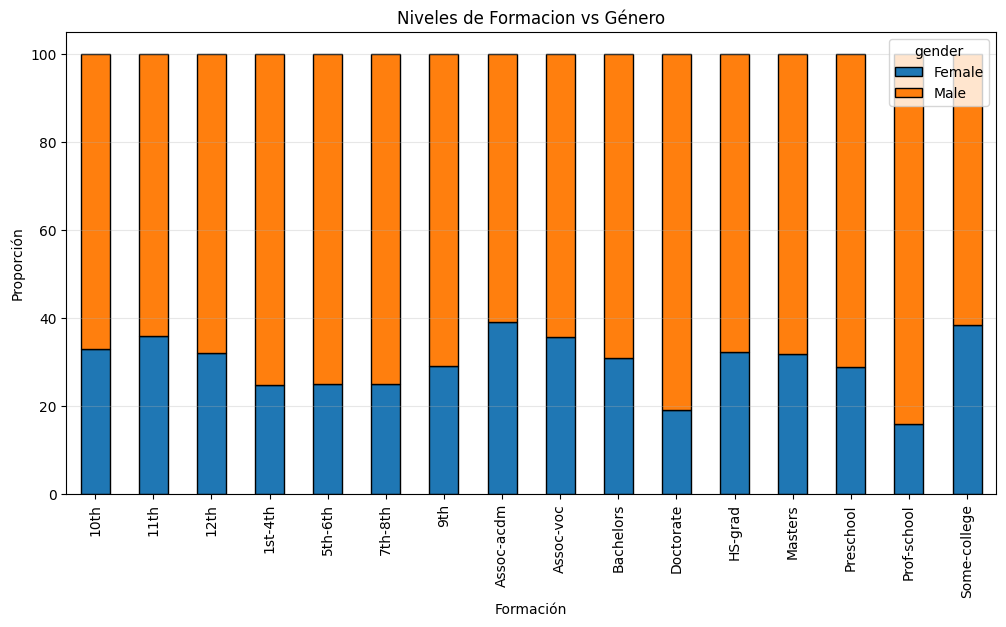

In [60]:
# Creamos la tabla entre la columna de la genero con la formación
tabla = pd.crosstab(
    df["education"],
    df["gender"],
    normalize="index"
) * 100

# Gráficamos el resultado

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    edgecolor="black"
)

plt.title("Niveles de Formacion vs Género")
plt.xlabel("Formación")
plt.ylabel("Proporción")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 💭 ¿Las personas que trabajan más de 40 horas semanales tienden a ser de mayor edad?

Las personas que trabajan más de 40 horas semanales tienden a ser ligeramente mayores que aquellas que trabajan 40 horas o menos. Sin embargo, la variabilidad de las edades es similar en ambos grupos y existen valores atípicos de personas de edad avanzada en ambas categorías.

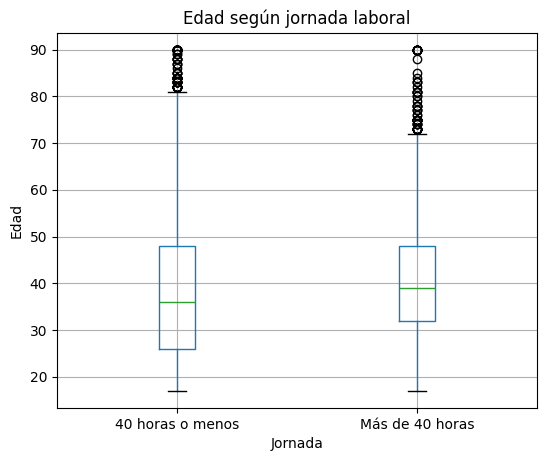

In [61]:
# Para este análisis realizaremos una nueva categoria
df["jornada"] = df["hours-per-week"].apply(
    lambda x: "Más de 40 horas" if x > 40 else "40 horas o menos"
)

# Gráficamos un gráfico de cajas apra ver el resultado
df.boxplot(column="age", by="jornada", figsize=(6,5))
plt.title("Edad según jornada laboral")
plt.suptitle("")
plt.xlabel("Jornada")
plt.ylabel("Edad")
plt.show()


## 💭 ¿Trabajar más horas implica ganar más?

El análisis mediante un diagrama de cajas muestra que las personas con ingresos superiores a 50K presentan una mediana de horas trabajadas por semana mayor que aquellas con ingresos inferiores o iguales a 50K. Aunque existe un solapamiento entre ambos grupos y numerosos valores atípicos, se observa una tendencia a que quienes perciben mayores ingresos trabajen jornadas más extensas. Sin embargo, el número de horas trabajadas por sí solo no explica completamente el nivel de ingresos, por lo que deben considerarse otras variables como la educación, la ocupación y la experiencia laboral.

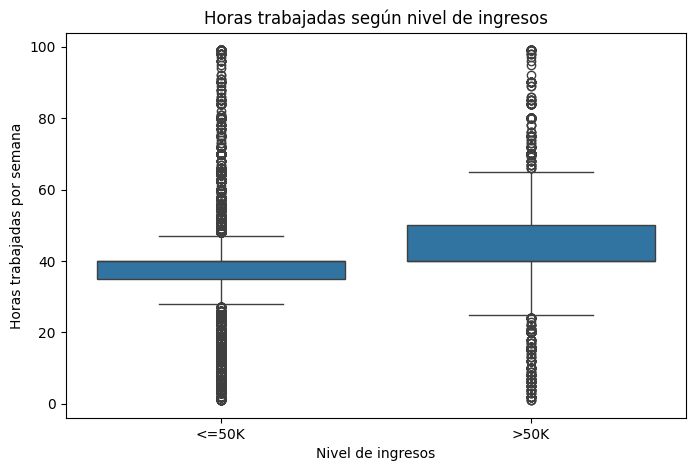

In [63]:
# Gráficamos este analisis
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Horas trabajadas según nivel de ingresos")
plt.xlabel("Nivel de ingresos")
plt.ylabel("Horas trabajadas por semana")

plt.show()

# 🧪 Correlaciones y heatmaps

En esta sección, vamos a realizar la interpretación de los datos proporcionados.

### 🚀 Matriz de correlacion

Generaremos una matriz de correlaccion con todas las columnas existentes en el dataset.

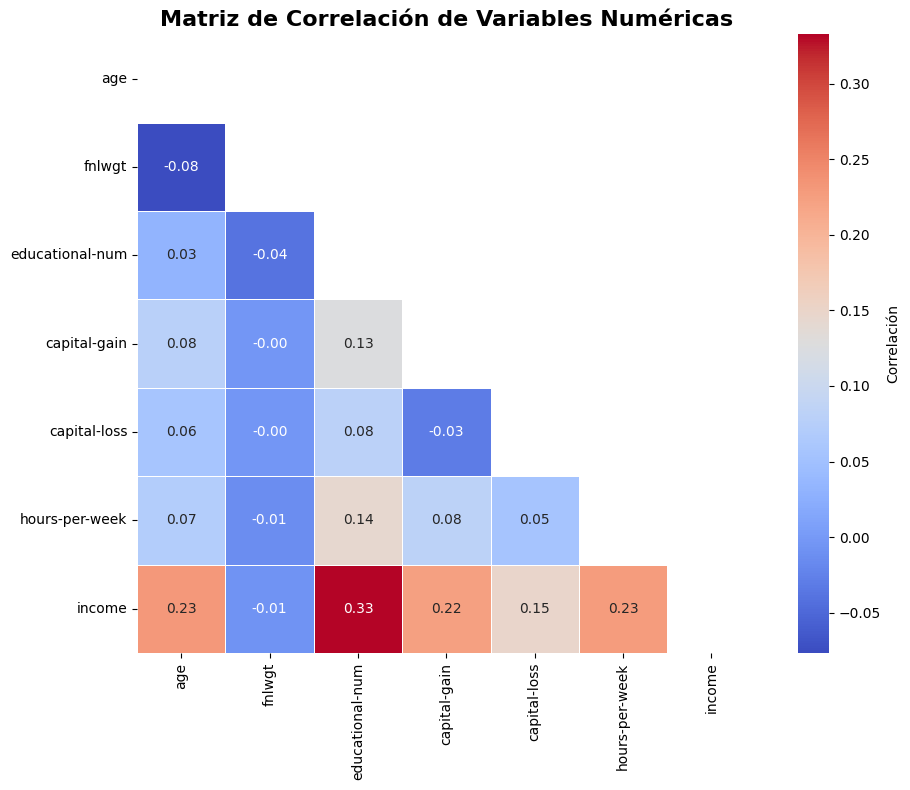

In [66]:

# Crearemos una copia del dataset
df_corr = df.copy()

# Convertimos a valores enteros para la matriz de correlación el income
df_corr["income"] = df_corr["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Calculamos la correlacion entre las columnas
corr = df_corr.select_dtypes(include="number").corr()

# Gráficamos
plt.figure(figsize=(10,8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label":"Correlación"}
)

plt.title(
    "Matriz de Correlación de Variables Numéricas",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



#### 🧠 Interpretación de Gráfico

Al incluir la variable objetivo income (ingresos), la matriz revela de forma clara qué características numéricas tienen el mayor impacto lineal en la predicción del nivel de ingresos.

📊 Hallazgos Principales y Predictores Clave
- El motor principal es la educación: La variable educational-num (años de estudio) presenta la correlación más fuerte con los ingresos (0.33). Estadísticamente, el nivel académico es el predictor numérico más sólido del dataset.
- Experiencia y jornada laboral: La edad (age) y las horas trabajadas por semana (hours-per-week) muestran un impacto idéntico de 0.23 sobre los ingresos. Esto confirma que la madurez profesional y el tiempo invertido en el trabajo empujan el salario al alza en la misma proporción.
- Capacidad de inversión: Las ganancias de capital (capital-gain) registran una correlación de 0.22 con income, demostrando que los ingresos altos están fuertemente vinculados a beneficios por inversiones financieras.
- Variable descartable: El peso muestral (fnlwgt) consolida una correlación nula de -0.01, lo que justifica su exclusión en modelos predictivos lineales, ya que no aporta valor para segmentar los ingresos.

💡 Conclusión: este análisis define con precisión tus cuatro variables numéricas clave: educación, edad, horas semanales y ganancias de capital. El dataset está listo y validado para avanzar a la fase de entrenamiento de modelos predictivos.

# 🤔 Hallazgos y conclusiones

## 🚀 ¿Qué podemos concluir en base al analisis realizado?


## ⭐ Respuesta

El análisis exploratorio del dataset **Adult** permitió comprender la estructura y calidad de los datos, así como identificar patrones relevantes entre las variables. Se observó que la mayoría de las personas posee ingresos iguales o inferiores a **50K**, evidenciando un desbalance en la variable objetivo. Además, las variables numéricas presentaron distribuciones diversas, con valores atípicos en características como **capital-gain**, **capital-loss** y **hours-per-week**, mientras que las variables categóricas mostraron una alta concentración en categorías como **Private** (tipo de empleo) y **United-States** (país de origen). La matriz de correlación indicó que variables como **education-num**, **age**, **hours-per-week** y **capital-gain** presentan una relación positiva con el nivel de ingresos, mientras que **fnlwgt** mostró una escasa relación con la variable objetivo.

Asimismo, el análisis de las hipótesis permitió identificar tendencias importantes en el comportamiento de los datos. Se encontró que las personas con un mayor nivel educativo presentan una mayor proporción de ingresos superiores a **50K**, y que quienes perciben mayores ingresos tienden a trabajar más horas por semana, aunque este factor por sí solo no determina el nivel salarial. En conjunto, los resultados indican que el ingreso está influenciado por múltiples variables demográficas, educativas y laborales, proporcionando una base sólida para el desarrollo de modelos predictivos que permitan estimar el nivel de ingresos a partir de las características de cada individuo.


# Aplicación en Entorno Laboral

## 🚀 Redacta una sección final de aplicación:
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **CARRERA DIAZ CHRISTIAN JAVIER**
Al usar estos modelos para poder predecir comportamientos en los datos de core bancario es muy interesante para auditorias y que puedan ser relevanteas para LOB(Line Of Bussiness). En mi campo no uso mucho la ciencia de datos para dar mejoras en los aplicativos actuales pero ayudarán a crear iniciativas para proponer a la empresa.